<a href="https://colab.research.google.com/github/d4nd14z/DataAnalytics/blob/main/MovilidadDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Universidad de La Salle**<br/>**Especialización en Análisis Estadístico para Ciencia de Datos**<br/>**Minería de Datos**<br/>**Febrero 2026**

###**Diccionario de Datos**<br/>Yellow Taxi Trip Data<br/>https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf


**VendorID:**<br/>Un código que indica el proveedor de TPEP que proporcionó el registro.<br/>1 = Creative Mobile Technologies, LLC<br/>2 = Curb Mobility, LLC
<br/>6 = Myle Technologies Inc<br/>7 = Helix

**tpep_pickup_datetime:**<br/>La fecha y hora en que se activó el medidor.

**tpep_dropoff_datetime:**<br/>La fecha y hora en que se desactivo el medidor.

**passenger_count:**<br/>Número de pasajeros en el vehículo.

**trip_distance:**<br/>La distancia del viaje transcurrida en millas informada por el taxímetro.

**RatecodeID:**<br/>Código de tarifa final vigente al final del viaje.<br/>1 = Tarifa estándar<br/>2 = JFK<br/>3 = Newark<br/>4 = Nassau o Westchester<br/>5 = Tarifa negociada<br/>6 = Viaje en grupo<br/>99 = Nulo/desconocido

**store_and_fwd_flag:**<br/>Esta bandera indica si el registro del viaje se mantuvo en la memoria del vehículo antes de enviarlo al proveedor (almacenamiento y reenvío), ya que el vehículo no tenía conexión con el servidor.<br/>Y = viaje con almacenamiento y reenvío<br/>N = no es un viaje con almacenamiento y reenvío

**PULocationID:**<br/>Zona de Taxi TLC en la cual se encontraba activado el taxímetro.

**DOLocationID:**<br/>TLC Taxi Zone in which the taximeter was disengaged.

**payment_type:**<br/>Un código numérico que indica cómo pagó el pasajero el viaje.<br/>0 = Viaje con tarifa flexible<br/>1 = Tarjeta de crédito<br/>2 = Efectivo<br/>3 = Sin cargo<br/>4 = Disputa<br/>5 = Desconocido<br/>6 = Viaje anulado

**fare_amount:**<br/>La tarifa por tiempo y distancia calculada por el taxímetro.
			Para obtener más información sobre las siguientes columnas, consulte https://www.nyc.gov/site/tlc/passengers/taxi-fare.page

**extra:**<br/>Extras y recargos varios.

**mta_tax:**<br/>Impuesto que se activa automáticamente en función de la tasa medida en uso

**tip_amount:**<br/>Importe de la propina<br/>Este campo se completa automáticamente para las propinas con tarjeta de crédito. No se incluyen las propinas en efectivo.

**tolls_amount:**<br/>Importe total de todos los peajes pagados en el viaje.

**improvement_surcharge:**<br/>Recargo por mejoras para viajes en la bajada de bandera. Este recargo comenzó a aplicarse en 2015.

**total_amount:**<br/>Importe total cobrado a los pasajeros. No incluye propinas en efectivo.

**congestion_surcharge:**<br/>Monto total recaudado en el viaje por el recargo por congestión del estado de Nueva York

**airport_fee:**<br/>Solo para recoger en los aeropuertos LaGuardia y John F. Kennedy.









### **0. Activación de Google Drive e Importación de Librerías**

In [54]:
# Activar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Importar librerías
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None) # Mostrar todas las columnas del DataFrame
#pd.set_option('display.max_rows', None)    # MOstrar todas las filas del DataFrame
%config InlineBackend.figure_format = 'retina' # Ajustar los graficos para que se vean más chimbita !!!

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Declaración de la función para mostrar heatmap de valores nulos**

In [55]:
# Funcion para dibujar heatmap de valores nulos
def mostrarValoresNulos():
  print("\n")
  plt.figure(figsize=(10, 6))
  # Asignamos el heatmap a la variable 'ax'
  ax = sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='Reds')
  # --- LE PONEMOS EL MARCO EXTERNO ---
  for spine in ax.spines.values():
      spine.set_visible(True)
      spine.set_color('black')
      spine.set_linewidth(1.5) # Un grosor decente para que se note
  plt.title('Valores nulos en el DataFrame')
  plt.show()

### **Declaración de la función para mostrar las gráficas en cada una de las variables**

In [56]:
# Funcion para dibujar los tres graficas
# Recibe como parametro el nombre de la columna que se va a graficar.
def mostrarGraficas(nombre_columna:str):
  # Se ajustan las graficas para que la figura sea: 1 fila, 3 columnas y el tamaño total (ancho, alto)
  fig, axes = plt.subplots(1, 3, figsize=(17, 5))

  # --- Diagrama 1: Histograma ---
  sns.histplot(x=df[nombre_columna], bins=50, ax=axes[0], color='royalblue', edgecolor='white', linewidth=0.5, alpha=0.7)
  axes[0].set_title('Histograma (Agrupado por Bins)')

  # --- Diagrama 2: Boxplot ---
  sns.boxplot(
    x=df[nombre_columna],
    ax=axes[1],
    color='#00FF00',     # Color de la caja
    width=0.7,           # Ancho de la caja
    linewidth=1,         # Ancho del borde de la caja
    fliersize=4,
    flierprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "none",
        "alpha": 0.4
    },
    boxprops={"edgecolor": "black", "alpha": 0.8} # Borde negro fino para resaltar el verde
  )
  axes[1].set_title('Boxplot (Diagrama de Cajas)')

  # --- Diagrama 3: Dispersión ---
  # Como es una sola variable, graficamos los puntos según su índice
  sns.scatterplot(x=df.index, y=df[nombre_columna], ax=axes[2], color='red')
  axes[2].set_title('ScatterPlot (Diagrama de Dispersión)')
  axes[2].set_xlabel(nombre_columna)

  # Ajustar el espacio entre gráficas para que no se encimen
  plt.tight_layout()
  plt.show()

### **1. Lectura del Dataset**

In [57]:
ruta_dataset = '/content/drive/MyDrive/Universidad de La Salle/Minería de datos/data/yellow_tripdata_2017-01 1.parquet'
try:
  if not os.path.exists(ruta_dataset):raise FileNotFoundError(f"No se encontró el archivo parquet de datos")
  # Se leen cerca de 10 millones de registros !!! Como la totalidad del archivo es exagerada se toma una muestra de 1.000.000 registros aleatorios !!!
  # Todo eso se hace con sample(n=100000, y se inicia el aleatorio en random_state=42)... pero se debe indicar que los registros los seleccionen aleatoriamente !!!! (para eso se usa random_state=42) se inicializa la semilla !!!
  # Si no se hace de esta manera se estarían introduciendo "Sesgos" dentro de los datos recolectados.
  df = pd.read_parquet(ruta_dataset, engine='pyarrow').sample(n=1000000, random_state=42)

except Exception as ex:
  print(f"Error: {ex}")

### **2. Información General**

In [58]:
print(f"El Dataset contiene {df.shape[0]} registros y {df.shape[1]} columnas.\n")
print(f"Información General del dataset: \n",'*'*50, '\n')
print(df.info(),'\n')
print(f"Estas son las columnas del dataset: \n",'*'*50, '\n')
print(df.columns,'\n')
print(f"Nombres de las columnas: \n", "*"*50)
print(f"VendorID : ID del Proveedor")
print(f"VendorID : ID del Proveedor")
print(f"Estos son los tipos de datos del dataset : \n",'*'*50, '\n')
print(df.dtypes.value_counts(),'\n')
print(f"Hacemos los unique() sobre las columnas tipo object\n", '*'*50)
df["store_and_fwd_flag"].unique() # Solo contiene valores categoricos ('N' and 'Y')
#df["congestion_surcharge"].unique() # Todos los valores están en None ?
#df["airport_fee"].unique() # Todos los valores estàn en None ?

El Dataset contiene 1000000 registros y 19 columnas.

Información General del dataset: 
 ************************************************** 

<class 'pandas.core.frame.DataFrame'>
Index: 1000000 entries, 2786484 to 1161948
Data columns (total 19 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   VendorID               1000000 non-null  int64         
 1   tpep_pickup_datetime   1000000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  1000000 non-null  datetime64[us]
 3   passenger_count        1000000 non-null  int64         
 4   trip_distance          1000000 non-null  float64       
 5   RatecodeID             1000000 non-null  int64         
 6   store_and_fwd_flag     1000000 non-null  object        
 7   PULocationID           1000000 non-null  int64         
 8   DOLocationID           1000000 non-null  int64         
 9   payment_type           1000000 non-null  int64         
 10  fare_am

array(['N', 'Y'], dtype=object)

### **3.Limpieza de Datos (Búsqueda de valores nulos) y valores atípicos**

Columna: VendorID                  | Sin Valores Nulos
Columna: tpep_pickup_datetime      | Sin Valores Nulos
Columna: tpep_dropoff_datetime     | Sin Valores Nulos
Columna: passenger_count           | Sin Valores Nulos
Columna: trip_distance             | Sin Valores Nulos
Columna: RatecodeID                | Sin Valores Nulos
Columna: store_and_fwd_flag        | Sin Valores Nulos
Columna: PULocationID              | Sin Valores Nulos
Columna: DOLocationID              | Sin Valores Nulos
Columna: payment_type              | Sin Valores Nulos
Columna: fare_amount               | Sin Valores Nulos
Columna: extra                     | Sin Valores Nulos
Columna: mta_tax                   | Sin Valores Nulos
Columna: tip_amount                | Sin Valores Nulos
Columna: tolls_amount              | Sin Valores Nulos
Columna: improvement_surcharge     | Sin Valores Nulos
Columna: total_amount              | Sin Valores Nulos
Columna: congestion_surcharge      | Nulos: 1000000
Columna: airp

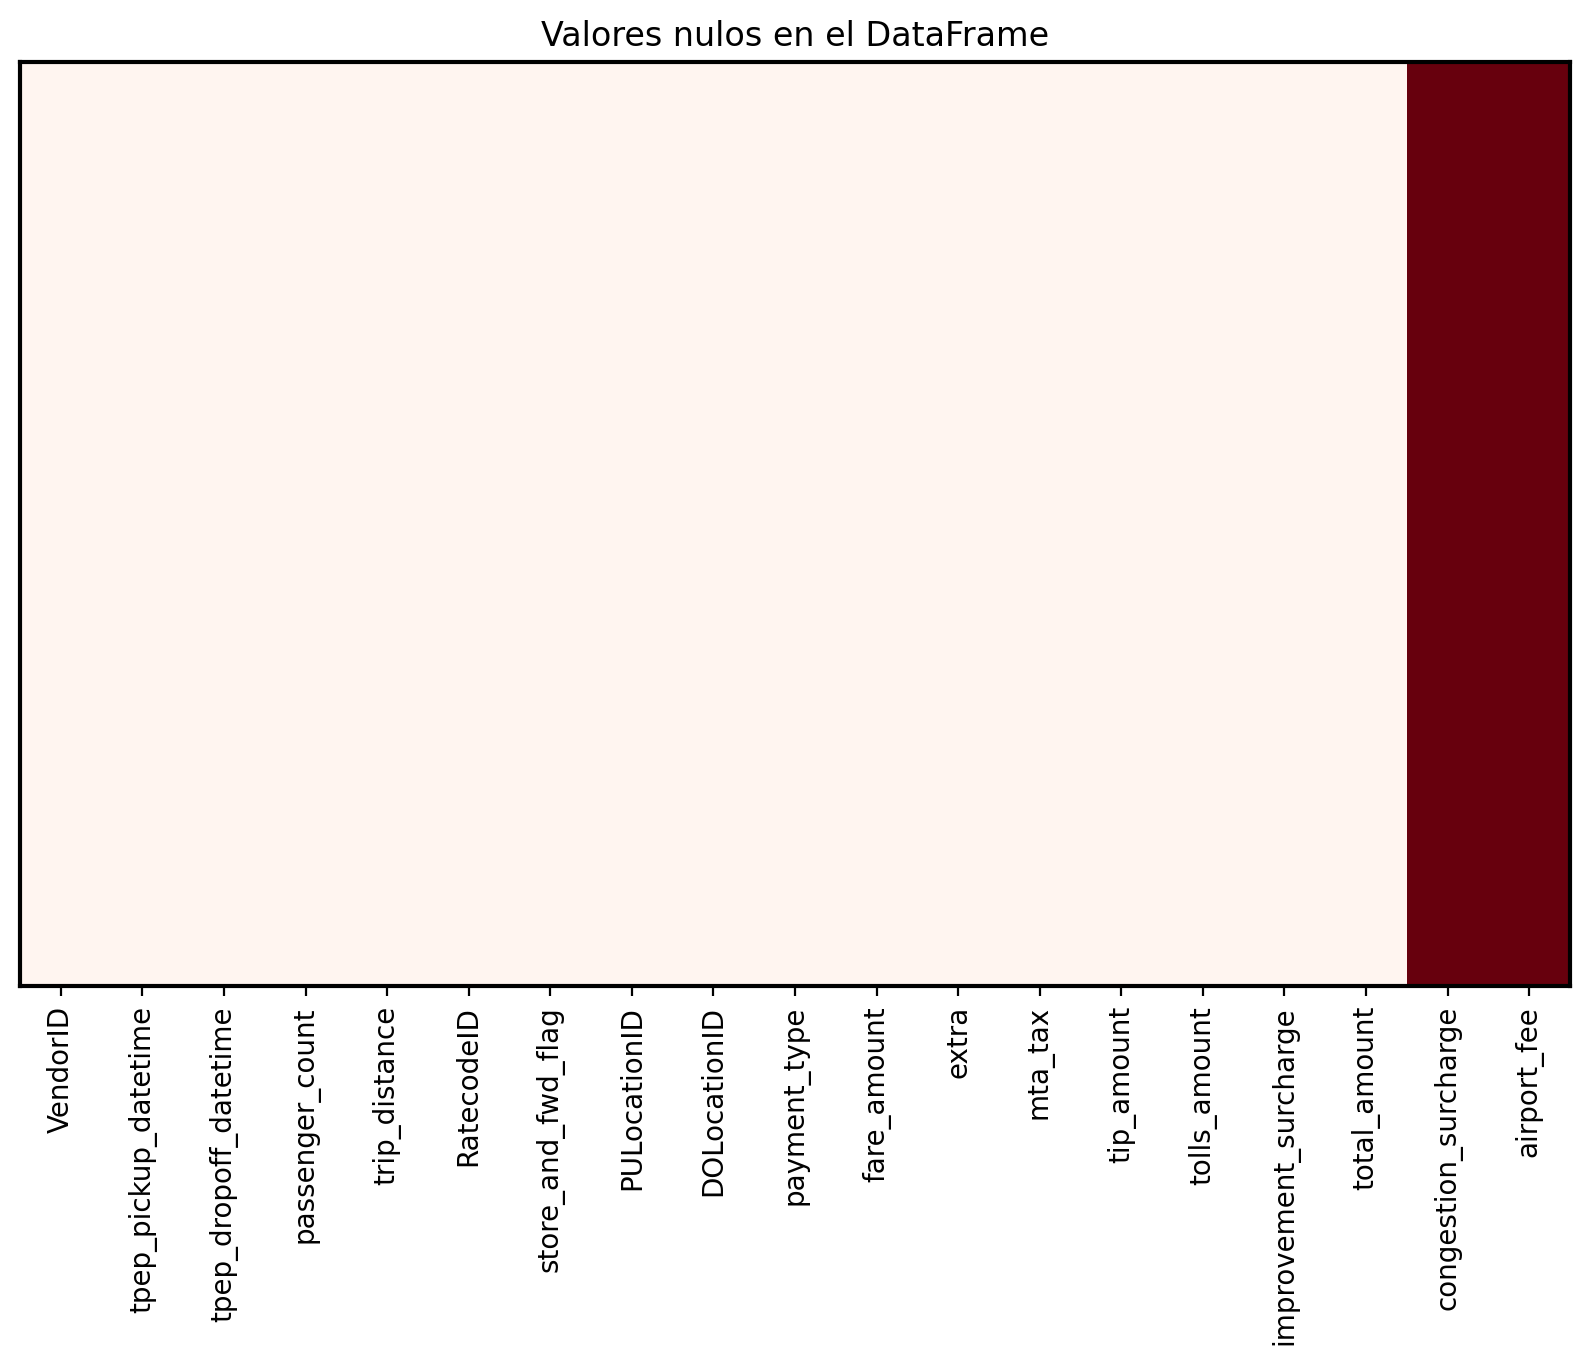

In [59]:
for col, cantidad in df.isnull().sum().items():
  if cantidad > 0:
    print(f"Columna: {col:25} | Nulos: {cantidad}")
  else:
    print(f"Columna: {col:25} | Sin Valores Nulos")

mostrarValoresNulos()

In [60]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,1000000.000000,1000000,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,1.547283,2017-01-16 22:31:16.508386,2017-01-16 22:46:03.770995,1.631612,2.815898,1.039129,164.065555,161.844804,1.33671,12.883884,0.323148,0.497508,1.751567,0.276771,0.299692,16.036650
min,1.000000,2017-01-01 00:00:09,2017-01-01 00:00:17,0.000000,0.000000,1.000000,1.000000,1.000000,1.00000,-100.000000,-4.500000,-0.500000,-15.840000,-5.540000,-0.300000,-100.300000
25%,1.000000,2017-01-09 10:09:53.250000,2017-01-09 10:25:18,1.000000,0.950000,1.000000,114.000000,107.000000,1.00000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.300000
50%,2.000000,2017-01-17 02:11:42.500000,2017-01-17 02:31:56,1.000000,1.600000,1.000000,162.000000,162.000000,1.00000,9.000000,0.000000,0.500000,1.320000,0.000000,0.300000,11.300000
75%,2.000000,2017-01-24 17:21:10.500000,2017-01-24 17:37:19.750000,2.000000,2.900000,1.000000,233.000000,234.000000,2.00000,13.500000,0.500000,0.500000,2.260000,0.000000,0.300000,16.640000
max,2.000000,2017-01-31 23:59:51,2017-02-01 23:36:59,9.000000,121.700000,99.000000,265.000000,265.000000,4.00000,625900.800000,4.500000,0.830000,322.000000,905.540000,0.300000,625901.600000
std,0.497760,NaN,NaN,1.275816,3.610895,0.462370,66.616798,70.659103,0.49069,625.981441,0.441578,0.038238,2.467632,1.799175,0.013217,626.028341


In [61]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
2786484,2,2017-01-10 14:48:29,2017-01-10 14:50:12,2,0.28,1,N,236,75,2,3.0,0.0,0.5,0.00,0.0,0.3,3.80,None,None
5185903,1,2017-01-18 05:38:29,2017-01-18 05:46:56,1,2.90,1,N,236,233,2,10.5,0.5,0.5,0.00,0.0,0.3,11.80,None,None
6364471,1,2017-01-21 16:21:26,2017-01-21 16:31:19,3,3.10,1,N,261,79,1,11.5,0.0,0.5,2.45,0.0,0.3,14.75,None,None
3234268,1,2017-01-11 22:15:59,2017-01-11 22:26:25,1,1.30,1,N,48,229,2,8.0,0.5,0.5,0.00,0.0,0.3,9.30,None,None
5381761,1,2017-01-18 18:22:03,2017-01-18 18:25:51,1,0.40,1,N,162,141,1,4.5,1.0,0.5,1.00,0.0,0.3,7.30,None,None


In [62]:
df.tail()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
2730828,1,2017-01-10 10:37:56,2017-01-10 10:45:54,1,0.40,1,N,162,162,2,6.5,0.0,0.5,0.00,0.0,0.3,7.30,None,None
8632010,2,2017-01-28 15:06:40,2017-01-28 15:26:07,1,2.54,1,N,246,142,1,14.5,0.0,0.5,2.00,0.0,0.3,17.30,None,None
1492454,2,2017-01-06 10:19:05,2017-01-06 10:21:25,1,0.81,1,N,239,142,2,4.5,0.0,0.5,0.00,0.0,0.3,5.30,None,None
1858256,2,2017-01-07 11:31:25,2017-01-07 11:44:22,1,2.08,1,N,113,87,1,10.0,0.0,0.5,2.16,0.0,0.3,12.96,None,None
1161948,2,2017-01-05 10:28:29,2017-01-05 10:36:25,1,0.95,1,N,100,234,1,7.0,0.0,0.5,1.56,0.0,0.3,9.36,None,None


### **3.1 Passenger Count**

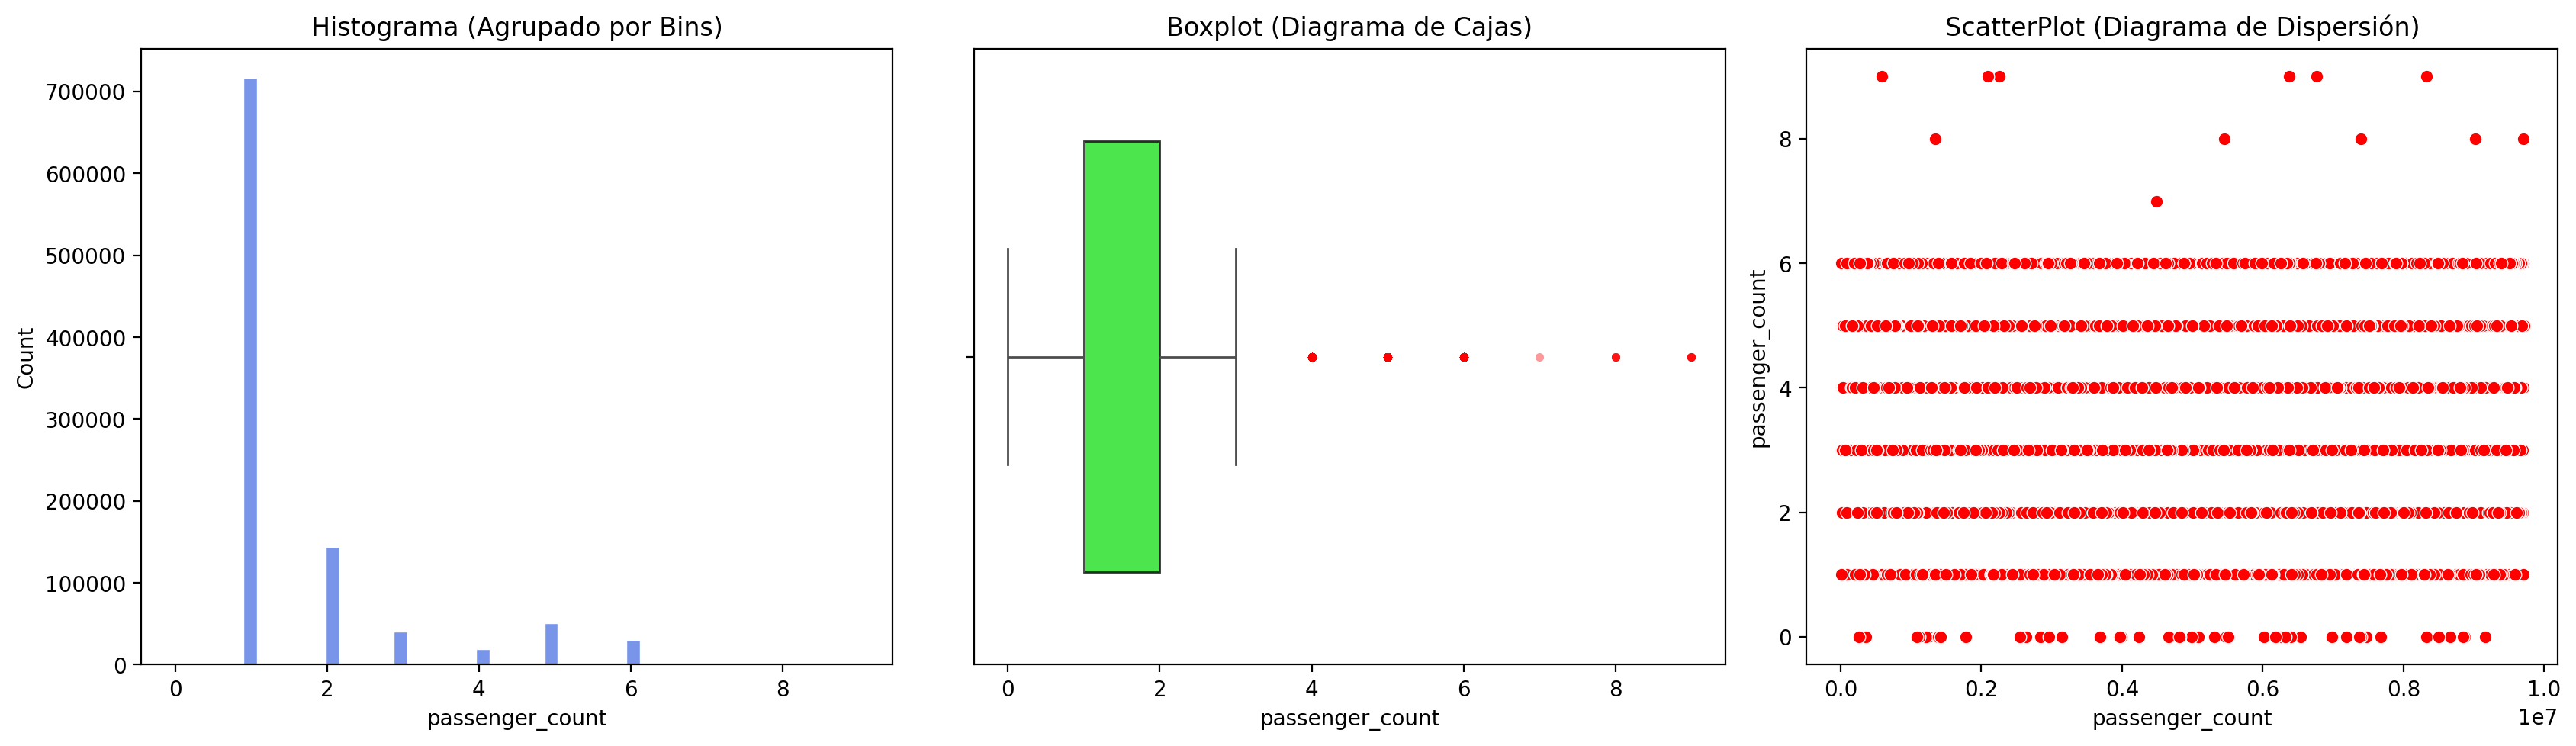

In [63]:
mostrarGraficas('passenger_count')

### **3.2 Trip Distance**

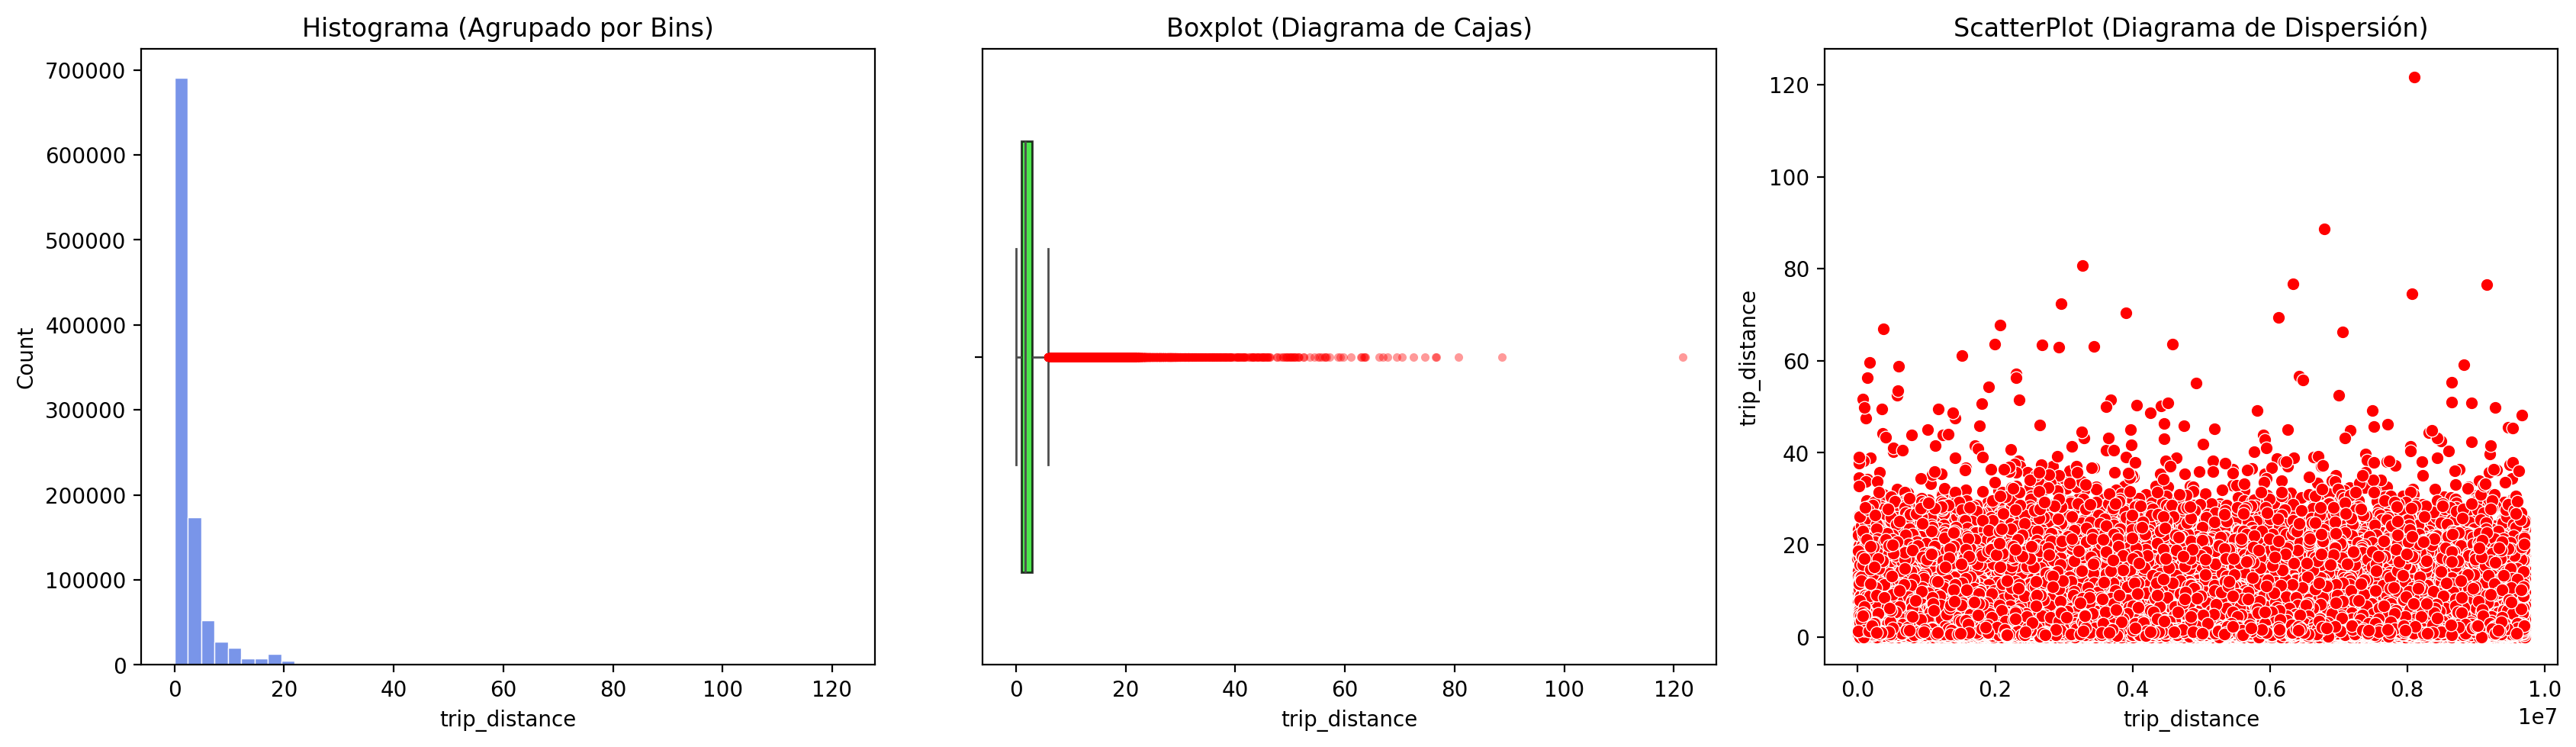

In [64]:
mostrarGraficas("trip_distance")

### **3.3 Fare Amount**

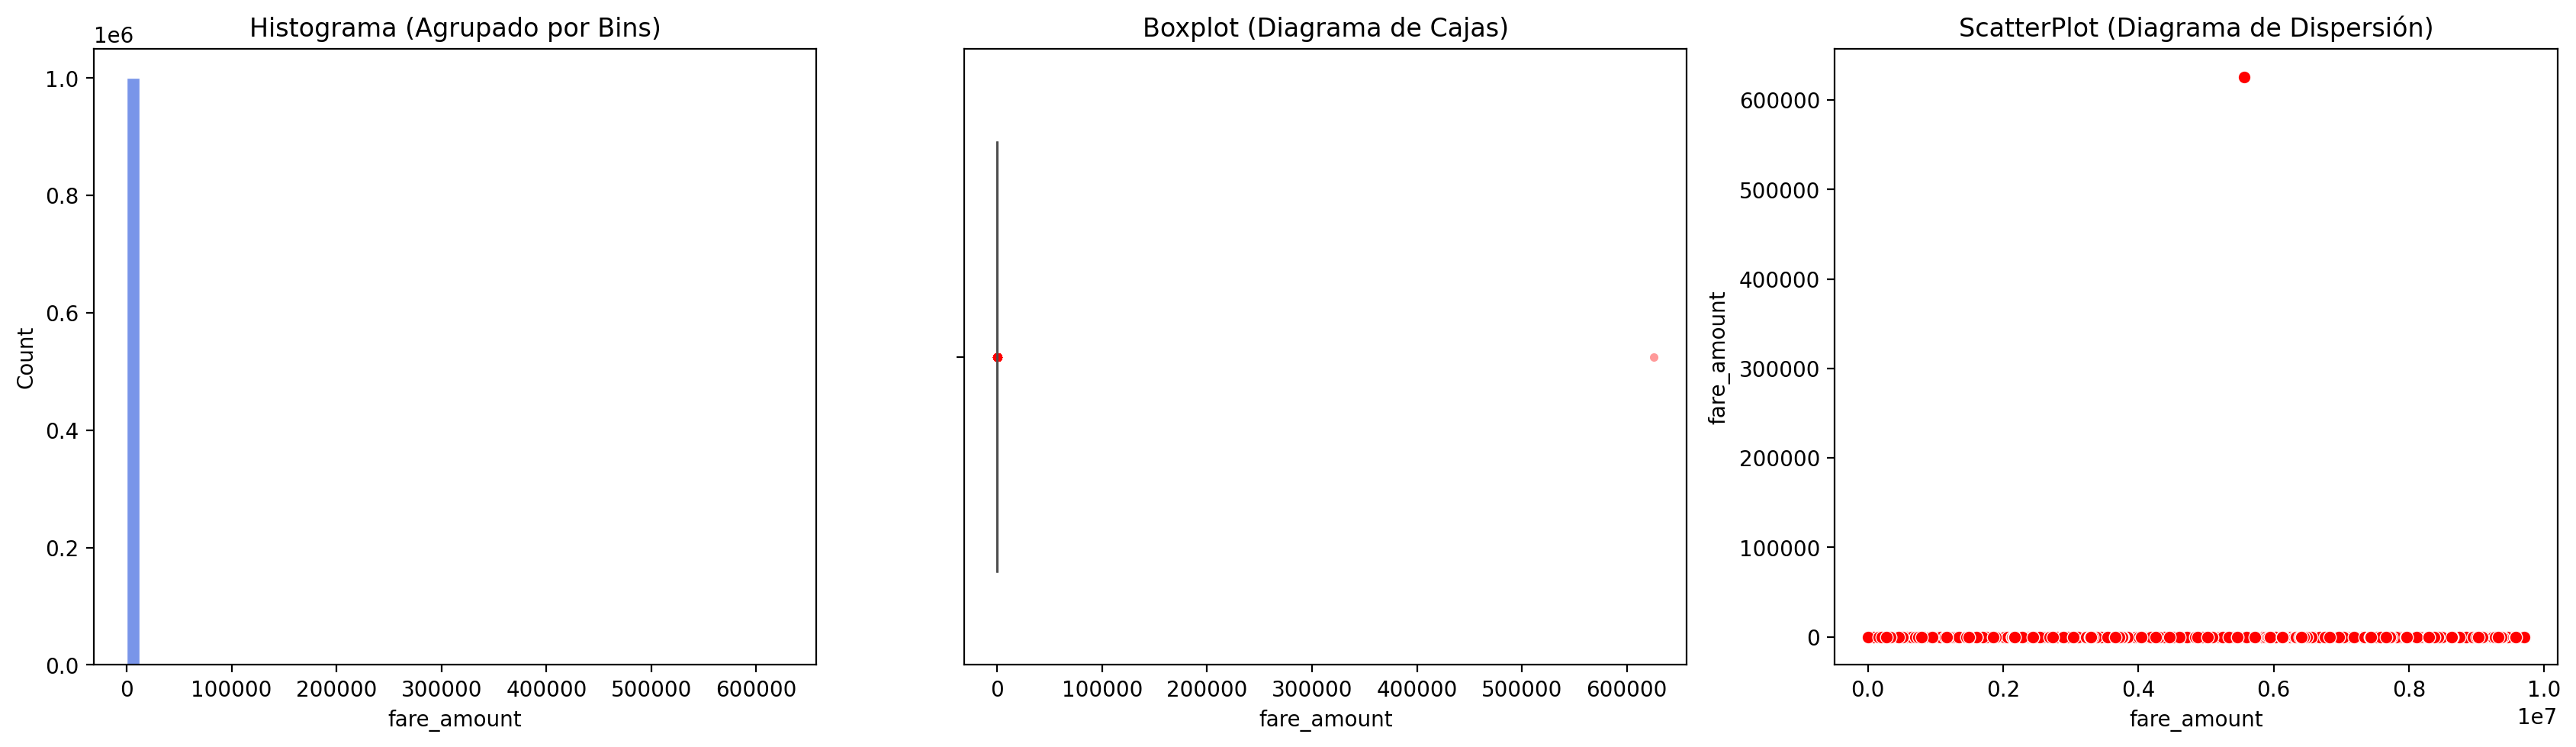

In [65]:
mostrarGraficas("fare_amount")

### **3.4 Extra**

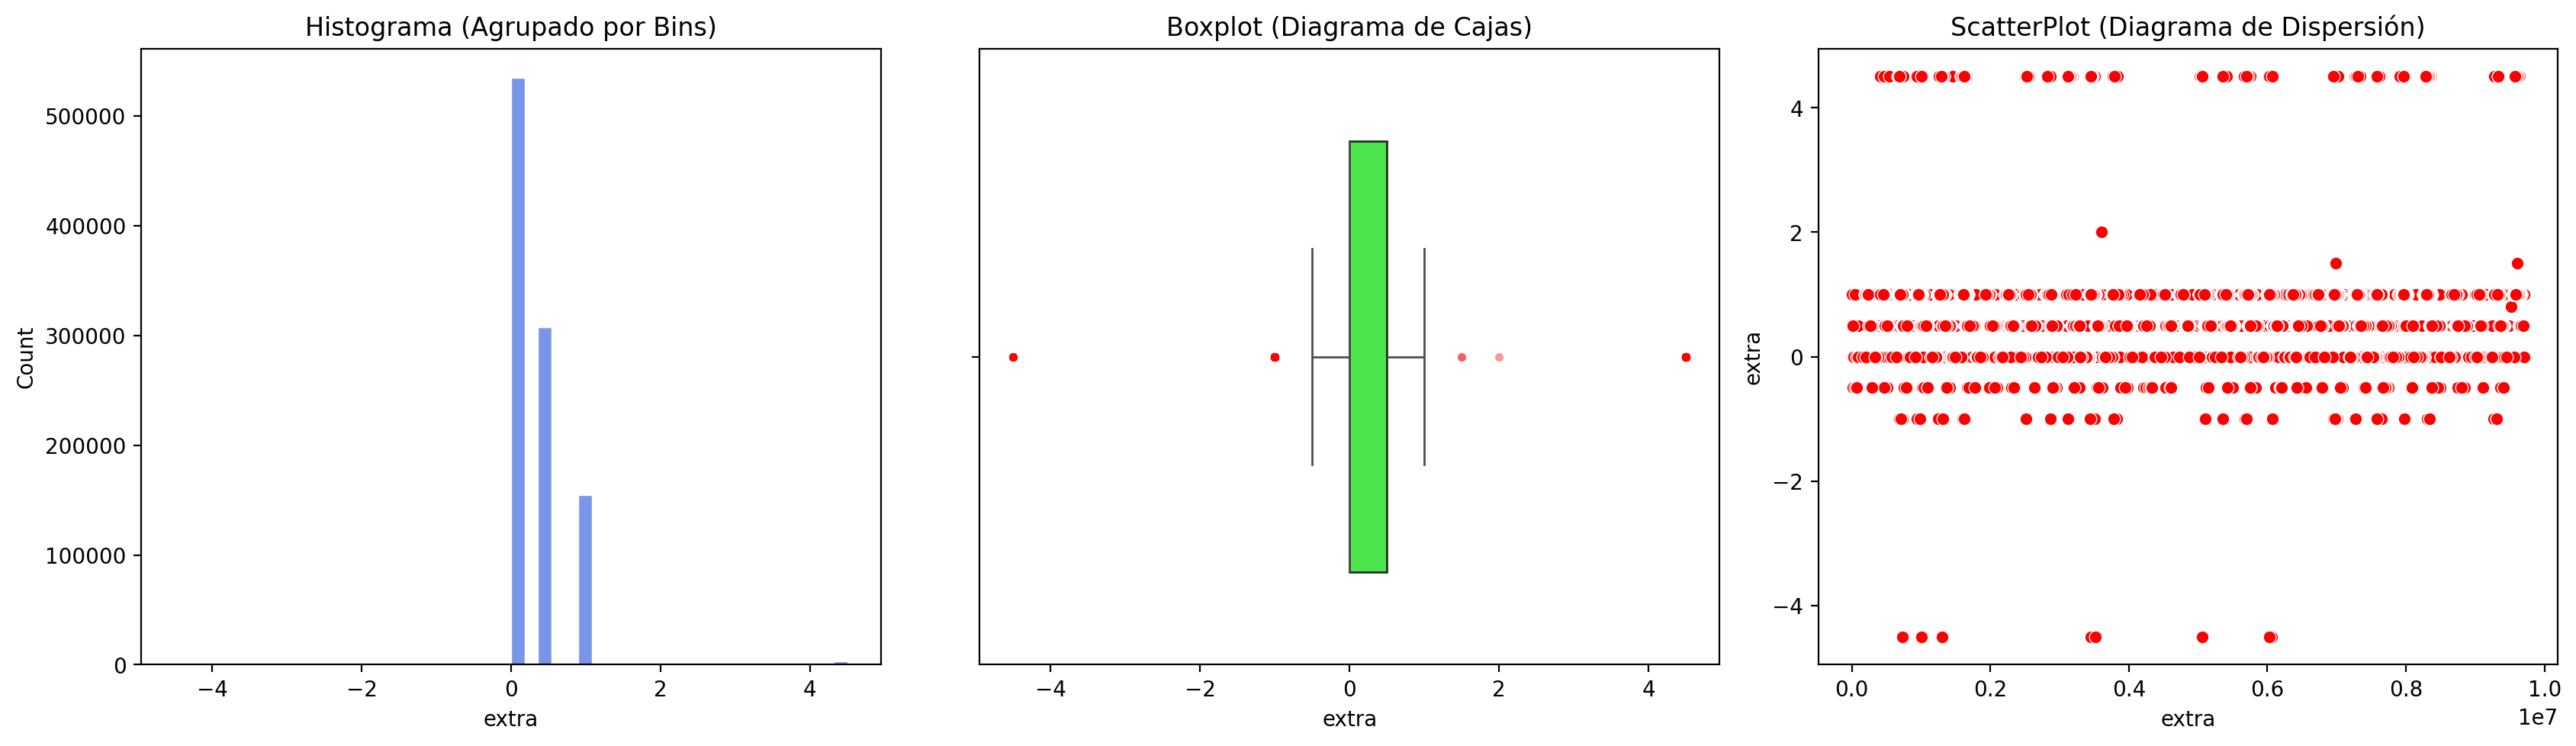

In [66]:
mostrarGraficas("extra")

### **3.5 MTA Tax**

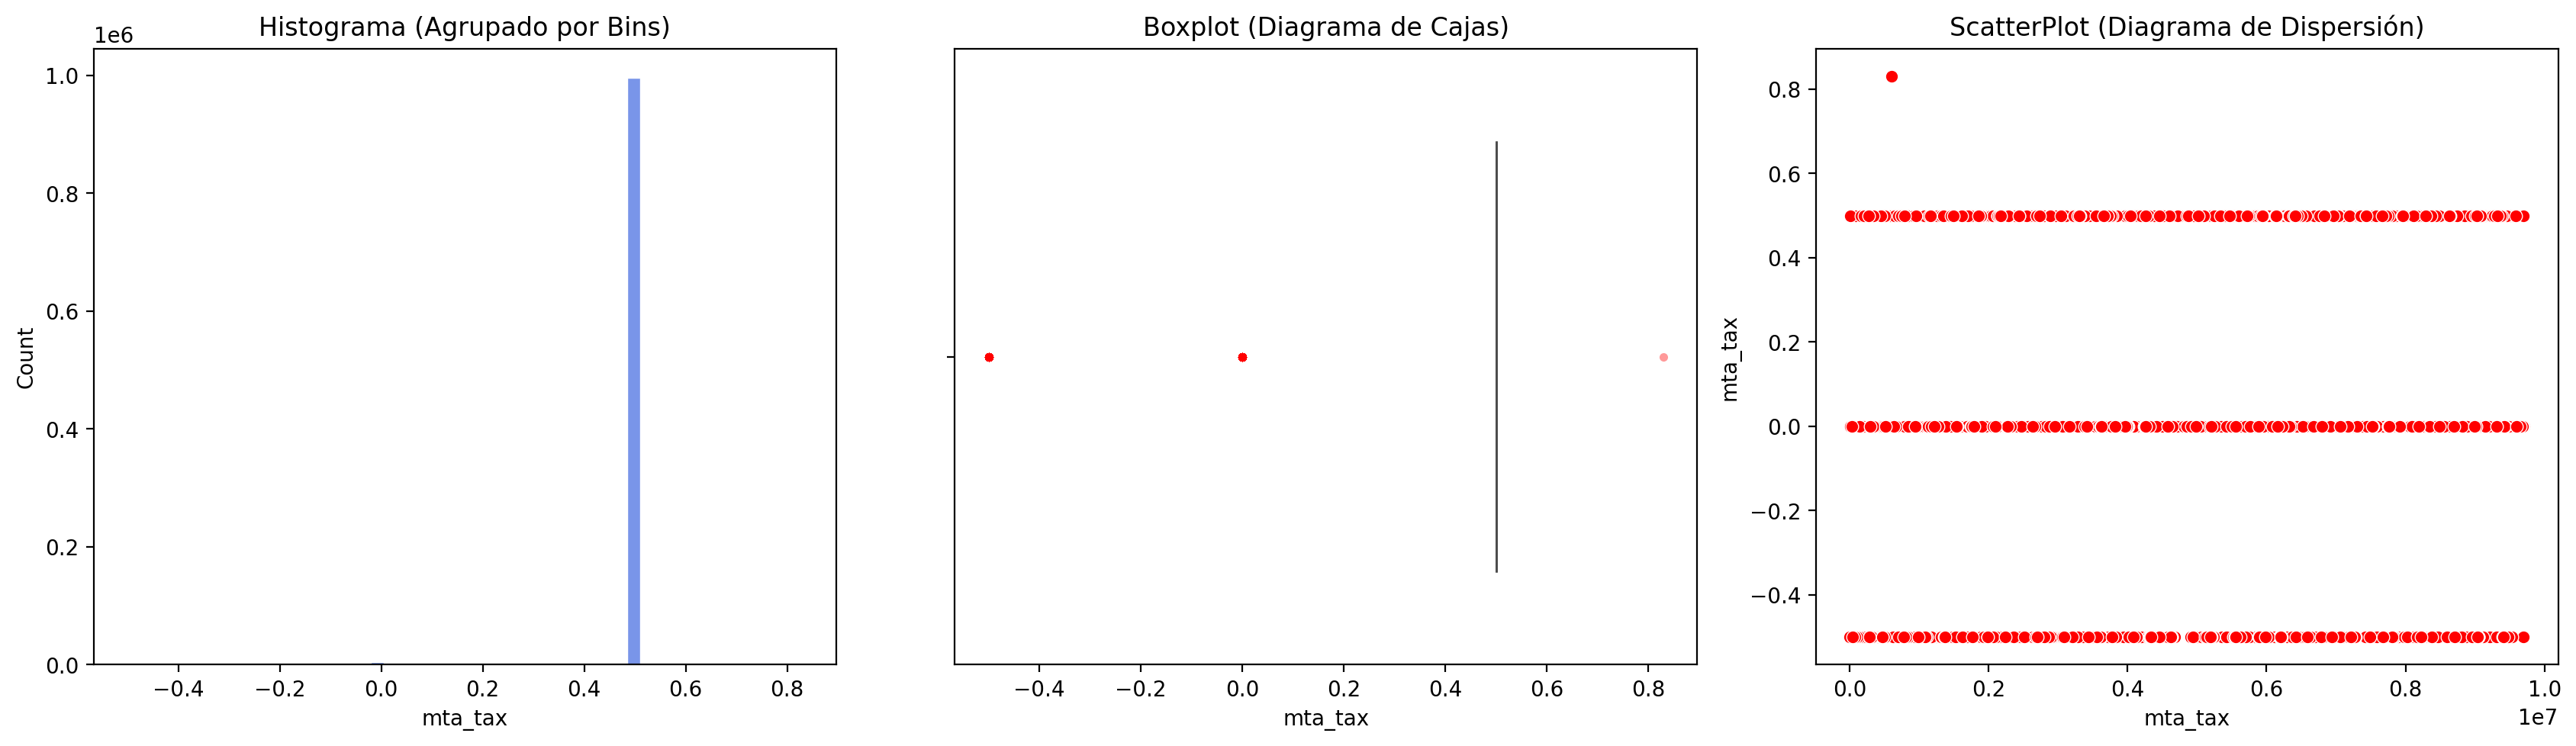

In [67]:
mostrarGraficas("mta_tax")

### **3.6 Tip Amount**

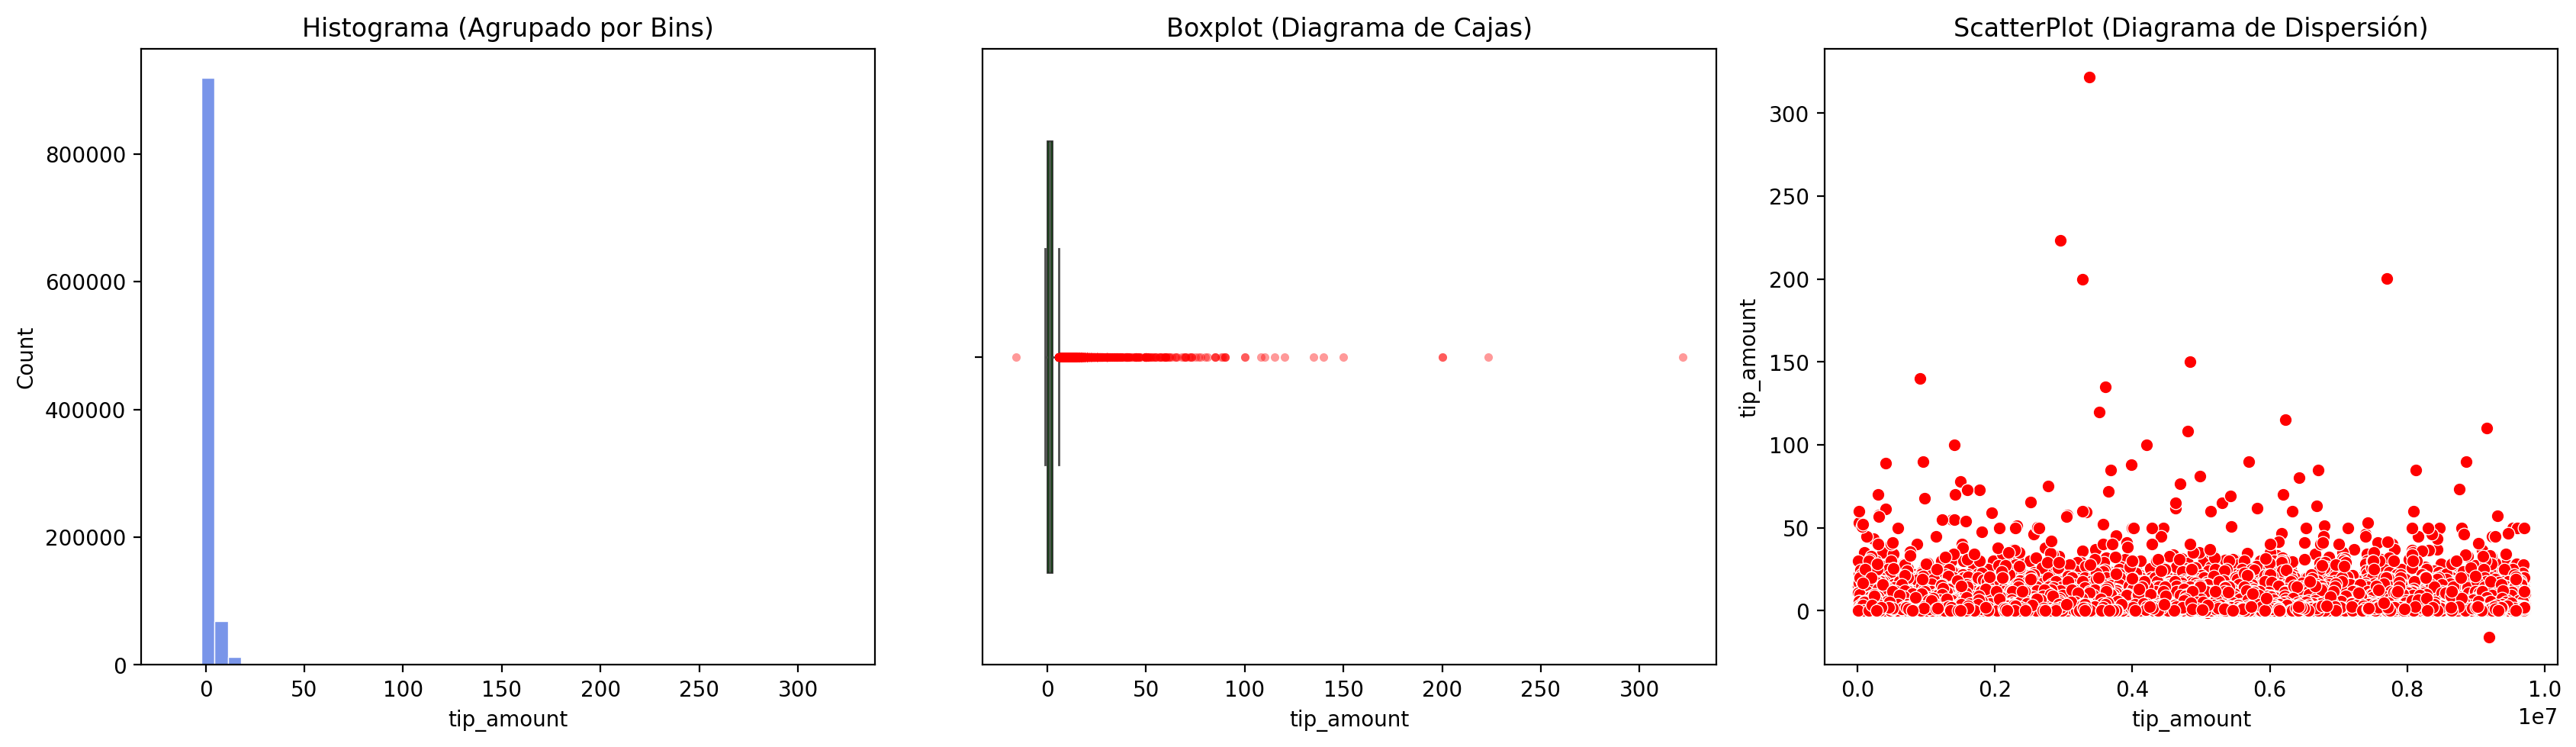

In [68]:
mostrarGraficas("tip_amount")

### **3.7 Tolls Amount**

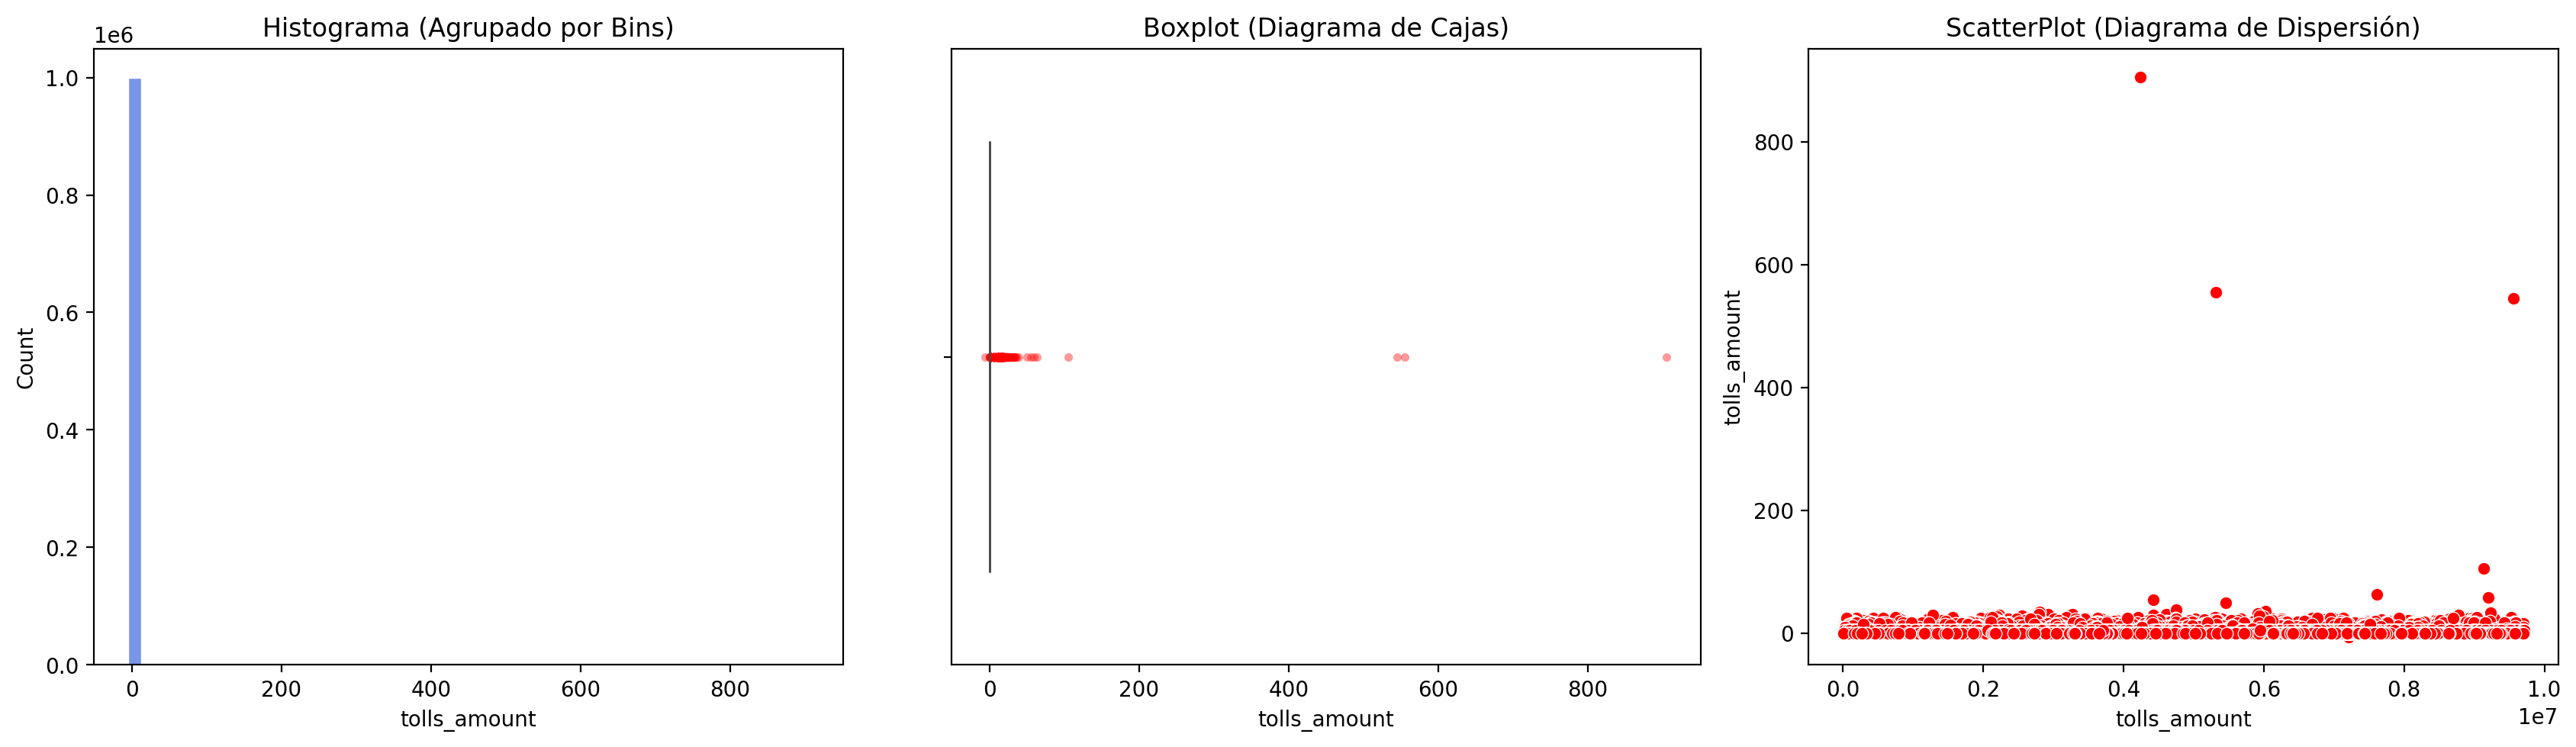

In [69]:
mostrarGraficas("tolls_amount")

### **3.8 Improvement Surcharge**

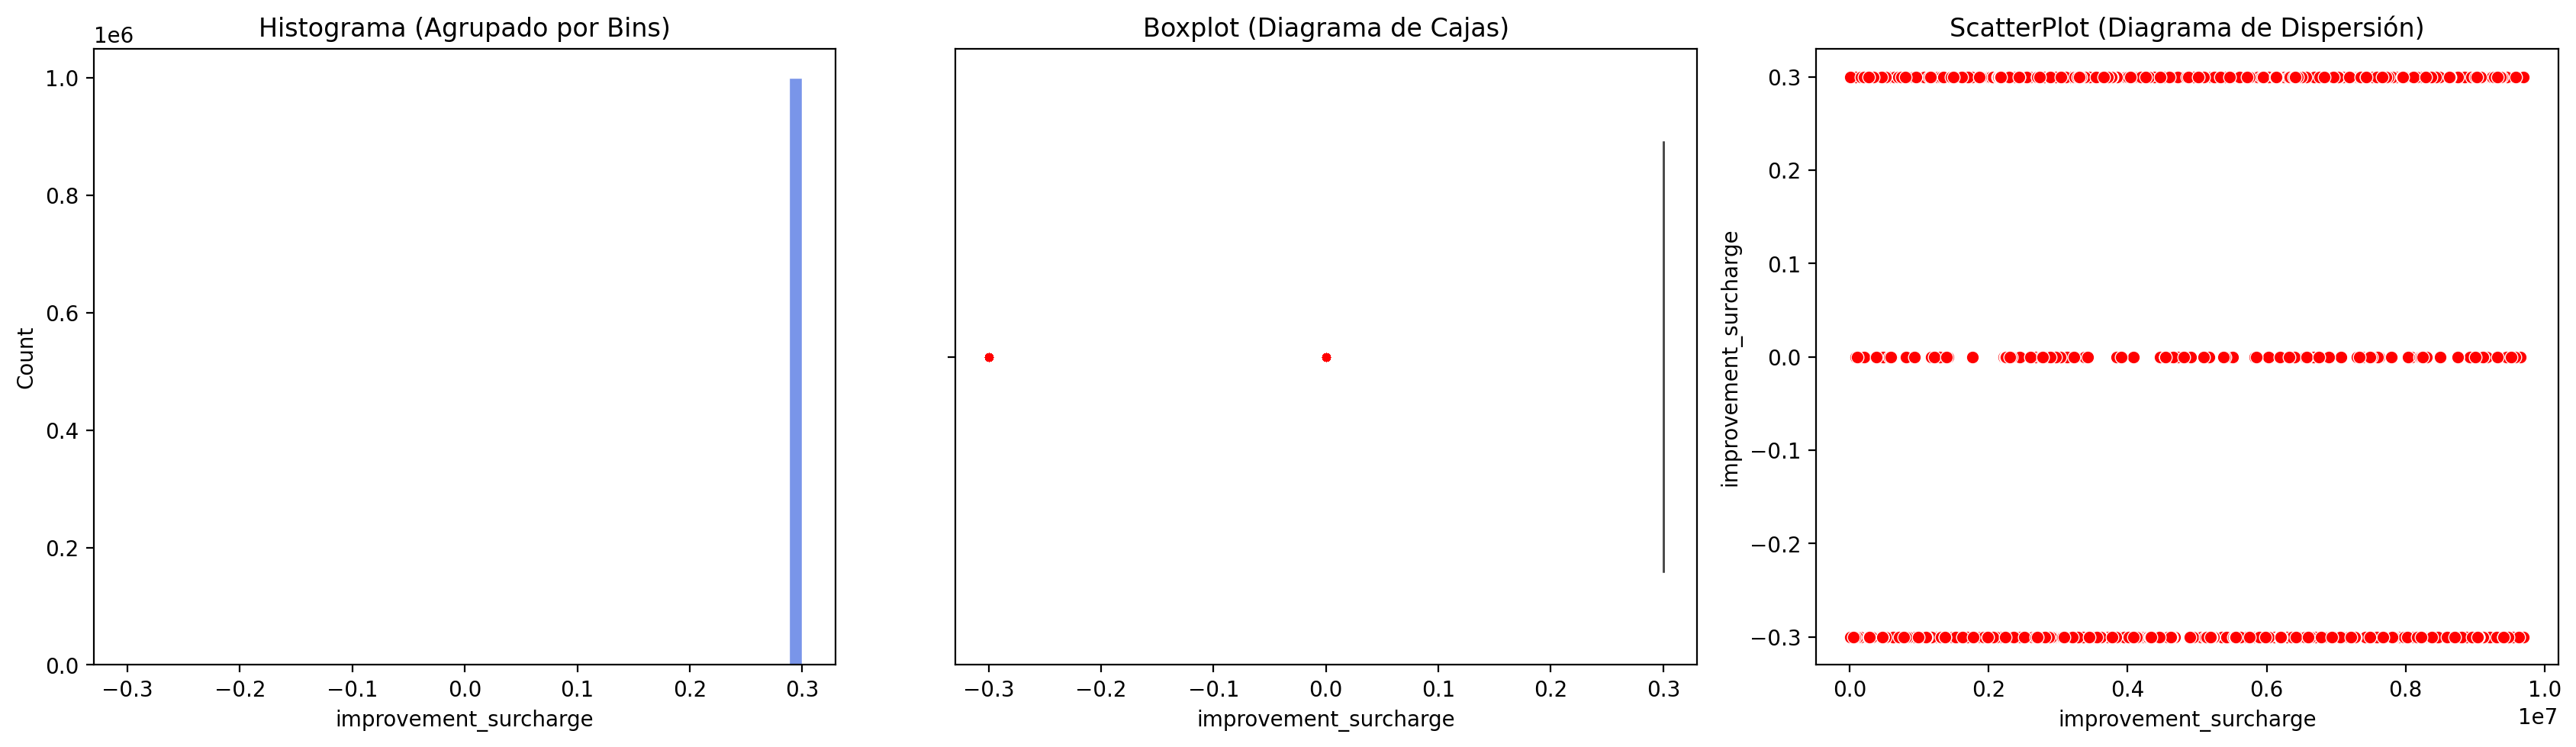

In [70]:
mostrarGraficas("improvement_surcharge")

### **3.9 Total Amount**

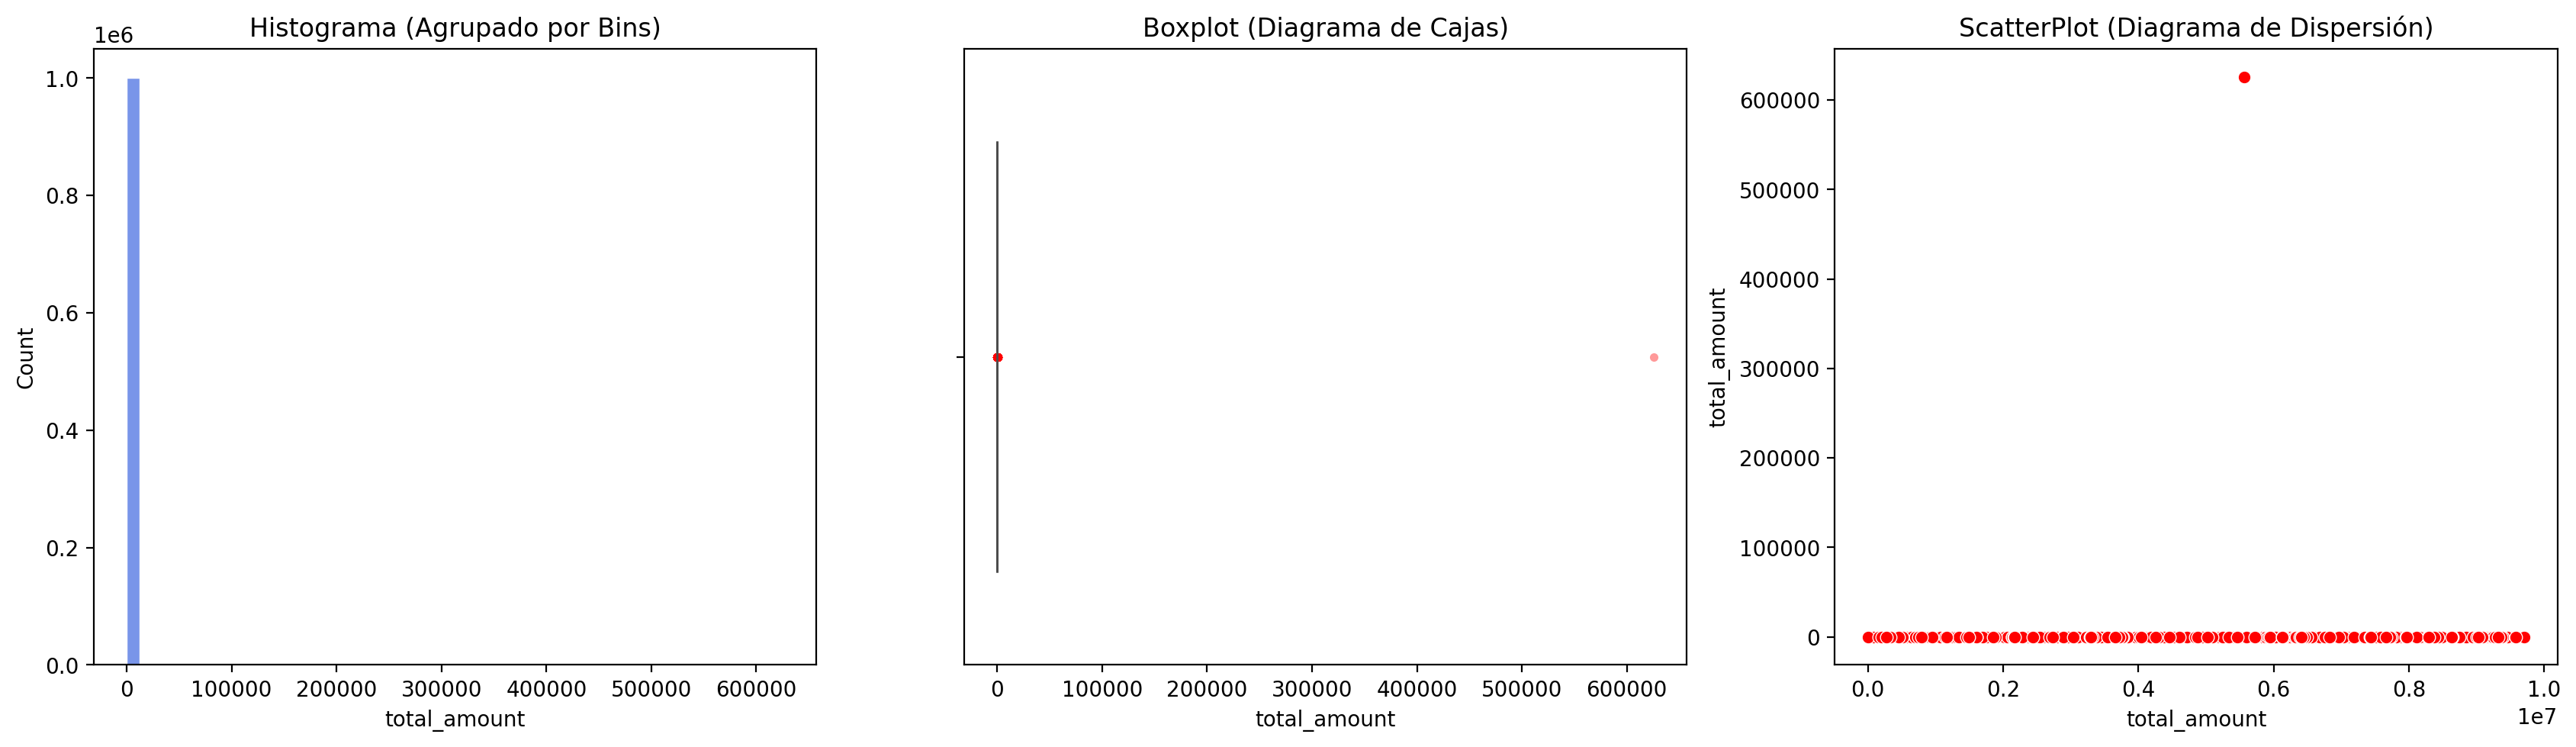

In [71]:
mostrarGraficas("total_amount")

### **En las variables congestion_surcharge y airport_fee todos los valores son nulos !!!**